### Task 1

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
 
df = pd.read_csv("cars.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [3]:
# horsepower is an object but should be a float
# origin is numeric but is categorical

In [4]:
df['horsepower'].describe()

count     398
unique     94
top       150
freq       22
Name: horsepower, dtype: object

### Task 2

In [5]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# the mean and median were close in values, the median was taken to better 
# represent the middle of the dataset values.

In [6]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


### Task 3

In [7]:
X = df.drop(columns=['mpg','car name'])
y = df['mpg']

# 'car name' can't be used in the model input because it is not numerical and can't
# be represented numerically. 

### Task 5

In [8]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
ohe = OneHotEncoder(sparse_output=False)
origin_array = ohe.fit_transform(X[['origin']])

origin_cols = ohe.get_feature_names_out(['origin'])
origin_df = pd.DataFrame(origin_array, columns=origin_cols, dtype=int)

df = pd.concat([df, origin_df], axis=1)
df.sample(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,origin_1,origin_2,origin_3
349,34.1,4,91.0,68.0,1985,16.0,81,3,mazda glc 4,0,0,1
309,41.5,4,98.0,76.0,2144,14.7,80,2,vw rabbit,0,1,0
120,19.0,4,121.0,112.0,2868,15.5,73,2,volvo 144ea,0,1,0
256,20.5,6,225.0,100.0,3430,17.2,78,1,plymouth volare,1,0,0
265,17.5,8,318.0,140.0,4080,13.7,78,1,dodge magnum xe,1,0,0
37,18.0,6,232.0,100.0,3288,15.5,71,1,amc matador,1,0,0
58,25.0,4,97.5,80.0,2126,17.0,72,1,dodge colt hardtop,1,0,0
139,14.0,8,302.0,140.0,4638,16.0,74,1,ford gran torino (sw),1,0,0
57,24.0,4,113.0,95.0,2278,15.5,72,3,toyota corona hardtop,0,0,1
382,34.0,4,108.0,70.0,2245,16.9,82,3,toyota corolla,0,0,1


### Task 4

Min and Max or std deviations are leaked when scaling before splitting as the values for the entire data set are used to calculate scales instead of the isolated test and training sets.

We would be including test data into training which inflates our perception on how well the model is working.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)
print(len(y_train))
print(len(y_test))


318
80


### Task 6

In [10]:
X_train.drop(columns=['origin','origin_1'])
X_test.drop(columns=['origin','origin_1'])

KeyError: "['origin_1'] not found in axis"

1. We dropped the `origin` column and the `origin_1` column. It doesn't matter which of the `origin_` columns is dropped because if the values of the others are both 0, you know that it must be 1 in the column that was dropped.
2. This mulitcollinearity is not that the columns are similar or describe similar things, it is defininitionally all the same thing. Numeric features that are multicollinear can affect each other, but these One-Hot columns are not influenced by other features, they're all describing the same feature.

### Task 7

In [12]:
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train[['cylinders','displacement','horsepower','weight','acceleration','model year']])

X_test_scaled = ss.transform(X_test[['cylinders','displacement','horsepower','weight','acceleration','model year']])

print(f'Mean from StandardScaler: {ss.mean_}  ||  \nStd Dev from StandardScalar: {ss.scale_}')

Mean from StandardScaler: [   5.43081761  191.90408805  103.13050314 2969.01572327   15.63993711
   76.10377358]  ||  
Std Dev from StandardScalar: [  1.68229589 102.82175033  37.02696765 839.29496266   2.75892081
   3.59750764]


### Task 8

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error as MAE

cars_df = pd.read_csv('cars.csv')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

nominal_cols = ['origin']
numeric_cols = ['cylinders','displacement','horsepower','weight','acceleration','model year']

preprocessor = ColumnTransformer([
    ('nominal',         OneHotEncoder(sparse_output=False, drop='first'),           nominal_cols),
    ('numeric',         StandardScaler(),                                           numeric_cols)
])

pipe = Pipeline([
    ('preprocessor',    preprocessor),
    ('model',           LinearRegression())
])

pipe.fit(X_train, y_train)
y_preds = pipe.predict(X_test)

r2 = r2_score(y_test, y_preds)
mae = MAE(y_test, y_preds)

print(f'R2 Score: {r2:.2f}')
print(f'MAE: {mae:.2f} MPG')

R2 Score: 0.84
MAE: 2.29 MPG


The pipeline is much more simple. The thing it 'enforces' that we had to be careful about is that the pipeline automatically maintains the train/test split when fitting the scalers.  We had to manually call `fit_transform` for the training set and `transform` for the test set.

### Advanced 1:

- The spread along the histogram looks even. There are however a couple of outliers on either end. At a glance, the scatter plot seems off, but considering the relatively small test size and small spread of values, we believe it to be fairly even.

- It's hard to say what exactly is limited by our model, at least with such a small sample size. Perhaps with a larger dataset, or with cross-validation, we could have a clearer picture.

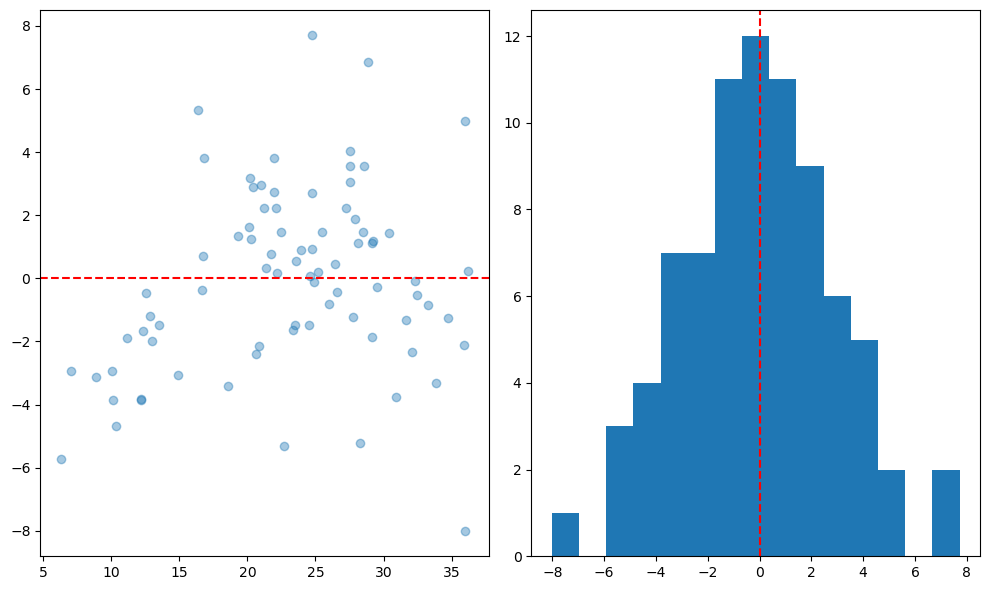

In [23]:
residuals = y_preds - y_test
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.scatter(x= y_preds,
            y= residuals,
            alpha=0.4)
plt.axhline(y=0, color='red', linestyle = '--')

plt.subplot(1,2,2)
plt.hist(residuals, bins=15)
plt.axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

### Advanced 2:

- The model with preprocessing performs slightly better.
- Skipping scaling with hurt the relationship features have with each other and their coefficients, as larger numbers would get weighted more havily.
- Skipping encoding would inaccurately represent the origins, as currently they would be interpreted as a numeric value.
- If you were working on a data set with a small set of features, consisting of numeric columns that were all the same scale, and did not have values which needed to be cleaned.

In [33]:
model = LinearRegression()
cars_df1 = pd.read_csv('cars.csv')
cars_df1['horsepower'] = pd.to_numeric(cars_df1['horsepower'], errors='coerce')
cars_df1['horsepower'] = cars_df1['horsepower'].fillna(cars_df1['horsepower'].median())
X = cars_df1.drop(columns=['mpg','car name', 'origin'])
y = cars_df1['mpg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

model.fit(X_train, y_train)
y_preds2 = model.predict(X_test)
r2_score = model.score(X_test, y_test)
print(f'No Preprocessing R2: {r2_score:.2f}')
print(f'Preproccessing R2: {r2:.2f}')
mae2 = MAE(y_test, y_preds2)
print(f'No Preprocessing MAE: {mae2:.2f}')
print(f'Preprocessing MAE: {mae:.2f}')

No Preprocessing R2: 0.82
Preproccessing R2: 0.84
No Preprocessing MAE: 2.47
Preprocessing MAE: 2.29
